# Adult / Census Income Dataset — End-to-End Classification Project

**Scope note:** `adult.data` is the classic UCI *Adult / Census Income* dataset. It has no header
row and no natural numeric target — its purpose is to predict whether a person's **income**
is `<=50K` or `>50K`. This is therefore a **classification-only** dataset, so per your request
this notebook covers **classification tasks only** (no regression section).

---
# Part 1 — Data Understanding


In [1]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


In [4]:
# Load the dataset (no header in the raw file -> assign UCI's official column names)
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv(r'E:\Job Base Programe\Data Sets\adult.data',
    header=None,
    names=columns,
    skipinitialspace=True   # strips the leading space after each comma, e.g. ' State-gov' -> 'State-gov'
)

print("First 5 records:")
df.head()


First 5 records:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
print("Last 5 records:")
df.tail()


Last 5 records:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


## Understand the dataset

In [6]:
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (32561, 15)


In [7]:
print("Columns:", list(df.columns))


Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [8]:
print("Data types:")
df.dtypes


Data types:


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

In [9]:
print("Dataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [10]:
print("Statistical summary (numerical):")
df.describe()


Statistical summary (numerical):


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [11]:
print("Statistical summary (categorical):")
df.describe(include='object')


Statistical summary (categorical):


C:\Users\AC\AppData\Local\Temp\ipykernel_12528\2507892247.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols_no_target = [c for c in cat_cols if c != 'income']

print("Number of rows            :", df.shape[0])
print("Number of columns         :", df.shape[1])
print("Number of numerical features  :", len(num_cols), "->", num_cols)
print("Number of categorical features:", len(cat_cols_no_target), "->", cat_cols_no_target)
print("Target variable            : income (<=50K / >50K)  -> CLASSIFICATION target")


Number of rows            : 32561
Number of columns         : 15
Number of numerical features  : 6 -> ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Number of categorical features: 8 -> ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Target variable            : income (<=50K / >50K)  -> CLASSIFICATION target


C:\Users\AC\AppData\Local\Temp\ipykernel_12528\1672273723.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


**Observations**
- 32,561 rows and 15 columns.
- Numerical features: `age`, `fnlwgt`, `education_num`, `capital_gain`, `capital_loss`, `hours_per_week`.
- Categorical features: `workclass`, `education`, `marital_status`, `occupation`, `relationship`, `race`, `sex`, `native_country`.
- Target: `income`, a binary classification label (`<=50K` vs `>50K`).


---
# Part 2 — Data Cleaning
## Missing Values


In [13]:
# This dataset uses '?' (often with a leading space, already stripped) to mark missing values
# instead of NaN. Convert those to proper NaN first so pandas' missing-value tools work correctly.
df = df.replace('?', np.nan)

missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct.round(2)})
missing_df[missing_df['Missing Count'] > 0]


,Missing Count,Missing %
workclass,1836,5.64
occupation,1843,5.66
native_country,583,1.79


In [14]:
# Handle missing values:
# - workclass, occupation, native_country are categorical -> impute with the mode (most frequent category)
for c in ['workclass', 'occupation', 'native_country']:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values after handling:")
df.isnull().sum().sum()


Missing values after handling:


np.int64(0)

## Duplicate Values

In [15]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)


Number of duplicate rows: 24


In [16]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (32537, 15)


## Incorrect Data Types

In [17]:
print(df.dtypes)
# All numeric columns are already correctly typed as int64.
# Categorical text columns (including target) are correctly typed as 'object' -> convert to 'category'
# dtype for memory efficiency and clarity.
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype('category')

df.dtypes


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object


C:\Users\AC\AppData\Local\Temp\ipykernel_12528\735257381.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


age                  int64
workclass         category
fnlwgt               int64
education         category
education_num        int64
marital_status    category
occupation        category
relationship      category
race              category
sex               category
capital_gain         int64
capital_loss         int64
hours_per_week       int64
native_country    category
income            category
dtype: object

## Unique Values of Categorical Columns

In [18]:
cat_cols_no_target = [c for c in cat_cols if c != 'income']
for c in cat_cols:
    print(f"--- {c} ({df[c].nunique()} unique values) ---")
    print(df[c].unique().tolist())
    print()


--- workclass (8 unique values) ---
['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']

--- education (16 unique values) ---
['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college', 'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school', '5th-6th', '10th', '1st-4th', 'Preschool', '12th']

--- marital_status (7 unique values) ---
['Never-married', 'Married-civ-spouse', 'Divorced', 'Married-spouse-absent', 'Separated', 'Married-AF-spouse', 'Widowed']

--- occupation (14 unique values) ---
['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners', 'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair', 'Transport-moving', 'Farming-fishing', 'Machine-op-inspct', 'Tech-support', 'Protective-serv', 'Armed-Forces', 'Priv-house-serv']

--- relationship (6 unique values) ---
['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried', 'Other-relative']

--- race (5 unique values) ---
['White', 'Black', 

---
# Part 3 — Exploratory Data Analysis (EDA)
## Univariate Analysis — Numerical Features


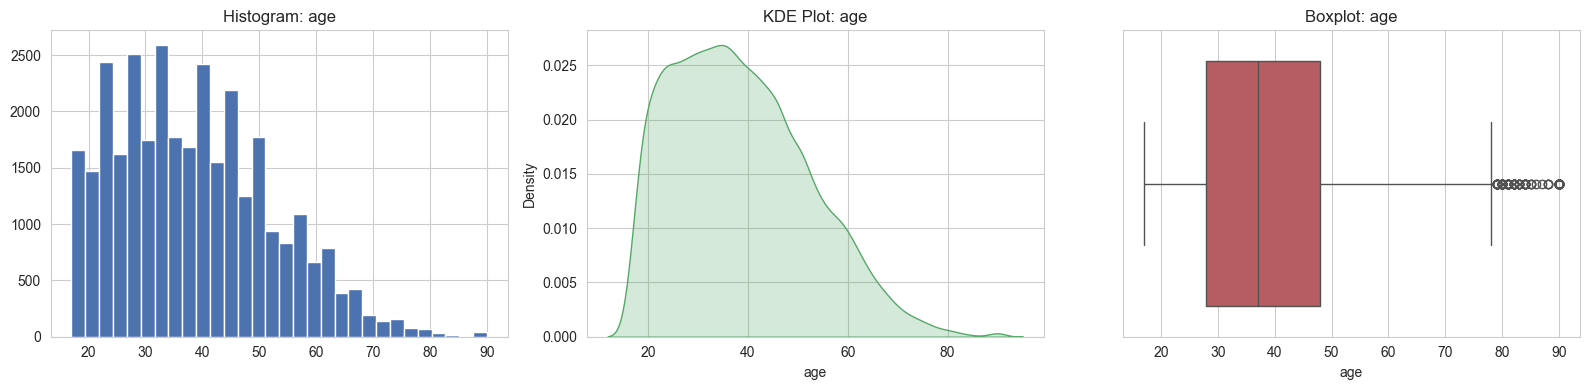

age: skew=0.56, mean=38.59, median=37.00



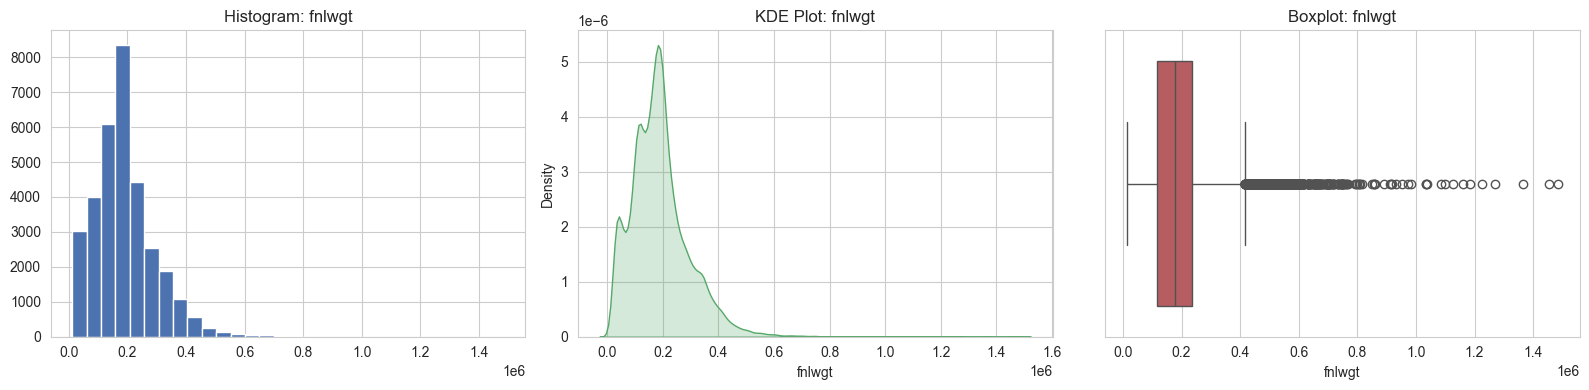

fnlwgt: skew=1.45, mean=189780.85, median=178356.00



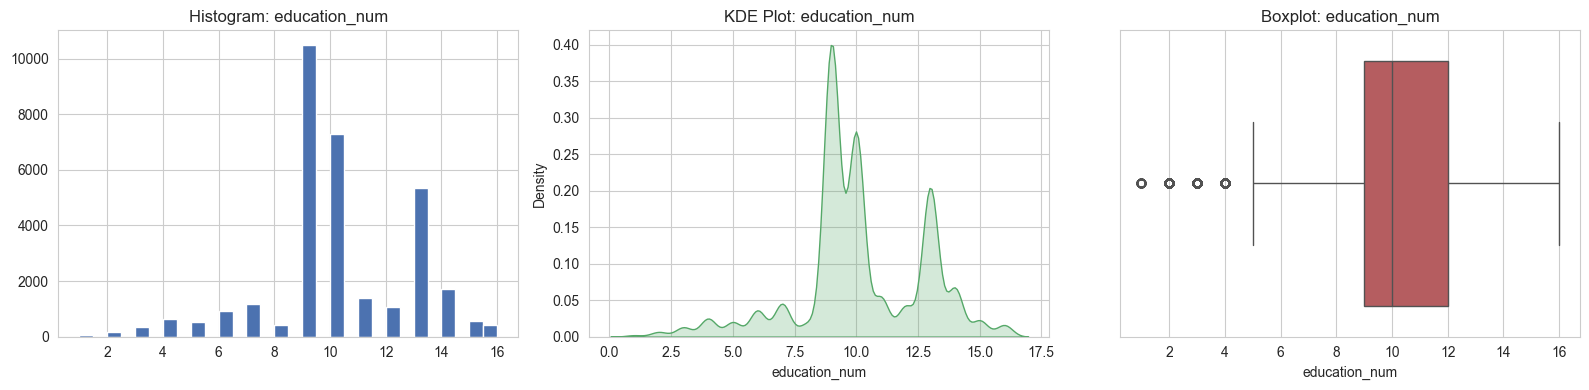

education_num: skew=-0.31, mean=10.08, median=10.00



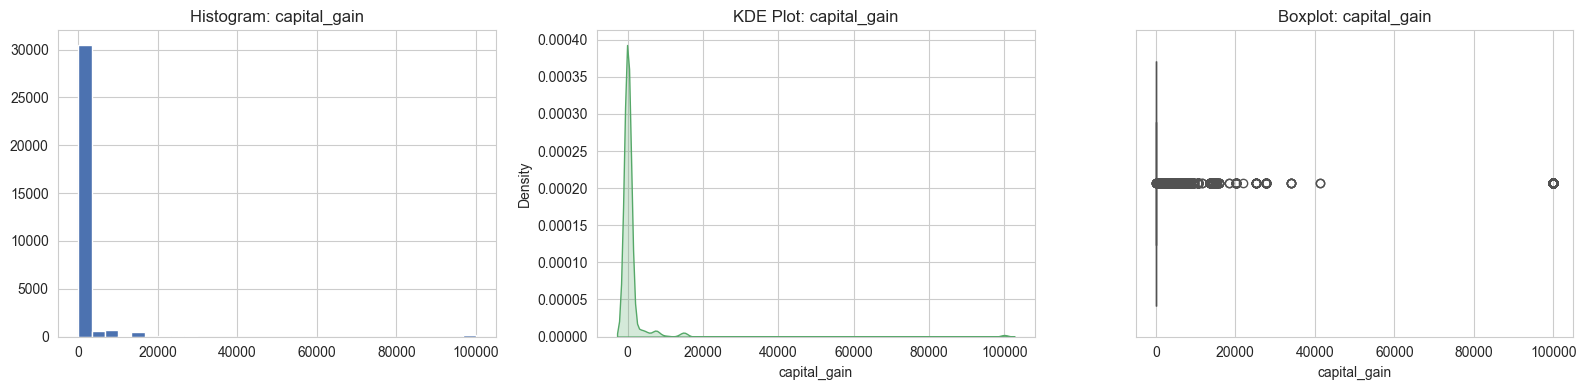

capital_gain: skew=11.95, mean=1078.44, median=0.00



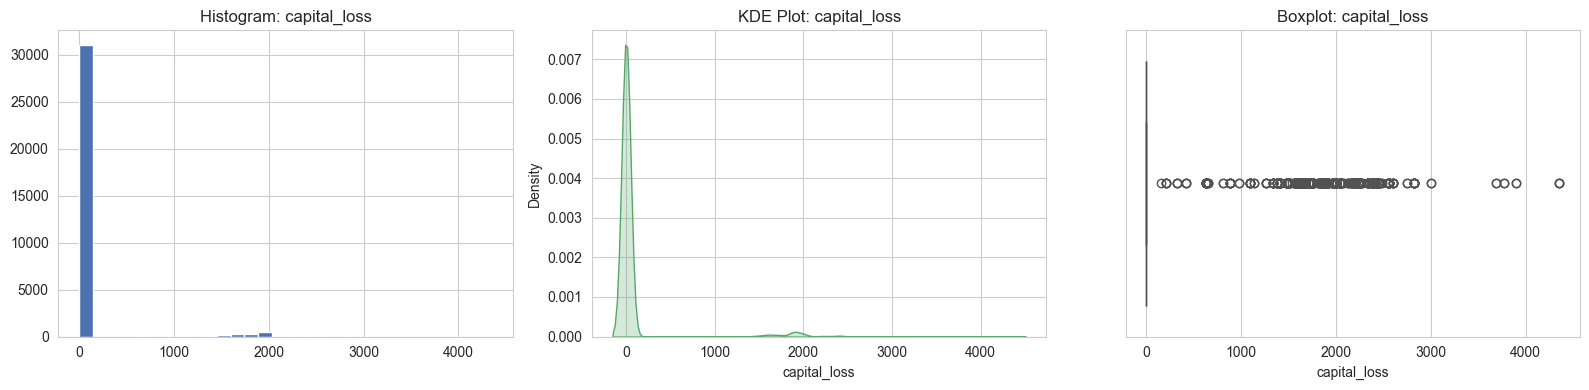

capital_loss: skew=4.59, mean=87.37, median=0.00



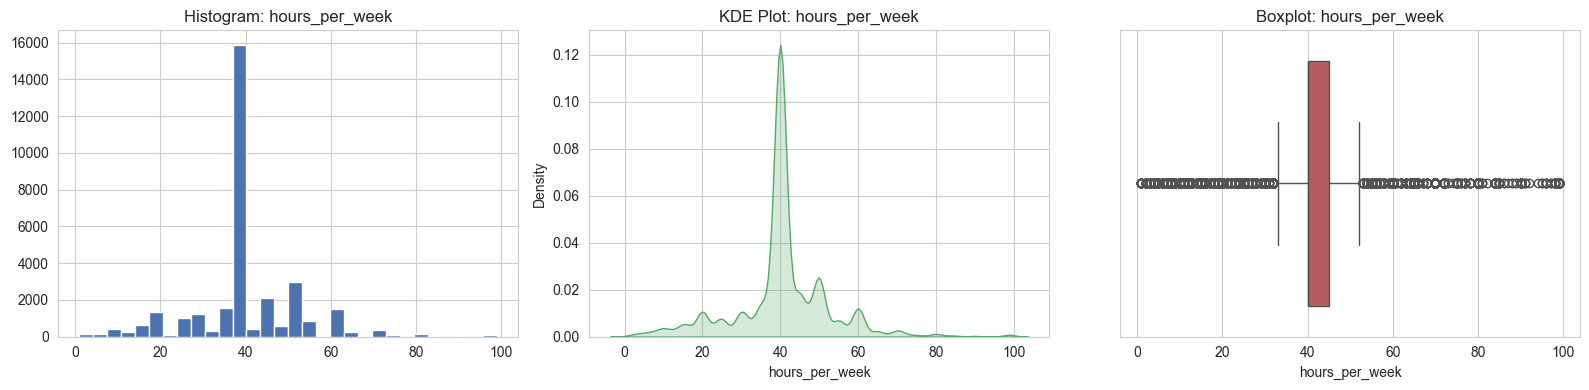

hours_per_week: skew=0.23, mean=40.44, median=40.00



In [19]:
numerical_features = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

for col in numerical_features:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    axes[0].set_title(f'Histogram: {col}')

    sns.kdeplot(df[col], ax=axes[1], fill=True, color='#55A868')
    axes[1].set_title(f'KDE Plot: {col}')

    sns.boxplot(x=df[col], ax=axes[2], color='#C44E52')
    axes[2].set_title(f'Boxplot: {col}')

    plt.tight_layout()
    plt.show()

    print(f"{col}: skew={df[col].skew():.2f}, mean={df[col].mean():.2f}, median={df[col].median():.2f}\n")


**Interpretation of distributions**
- **age**: Right-skewed, most working adults are 25–50, fewer at the elderly end.
- **fnlwgt**: A census sampling weight (not a real-world quantity) — heavily right-skewed with extreme outliers; it has no direct socio-economic meaning by itself.
- **education_num**: Roughly bell-shaped, centered around high-school/some-college (9–13), a discrete ordinal encoding of `education`.
- **capital_gain / capital_loss**: Extremely right-skewed — the vast majority of people report 0, with rare very large values (investment income), producing many boxplot "outliers" by construction.
- **hours_per_week**: Sharp peak at 40 (standard full-time week), with a spread of both part-time and overtime workers.


## Univariate Analysis — Categorical Features

C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


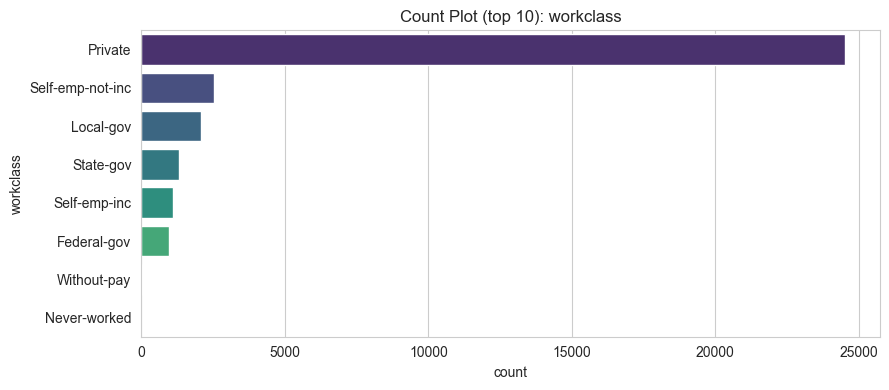

workclass
Private             24509
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
Most frequent category in 'workclass': Private



C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


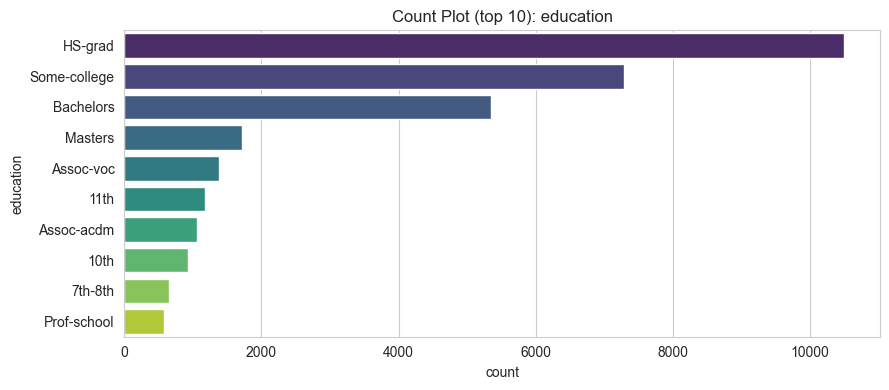

education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
Name: count, dtype: int64
Most frequent category in 'education': HS-grad



C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


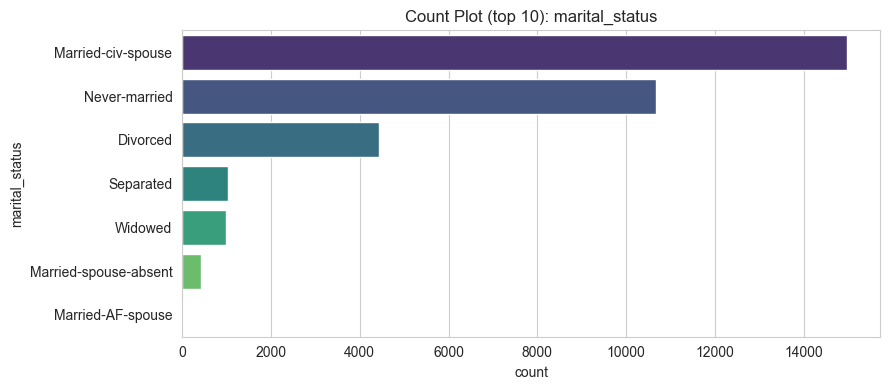

marital_status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
Most frequent category in 'marital_status': Married-civ-spouse



C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


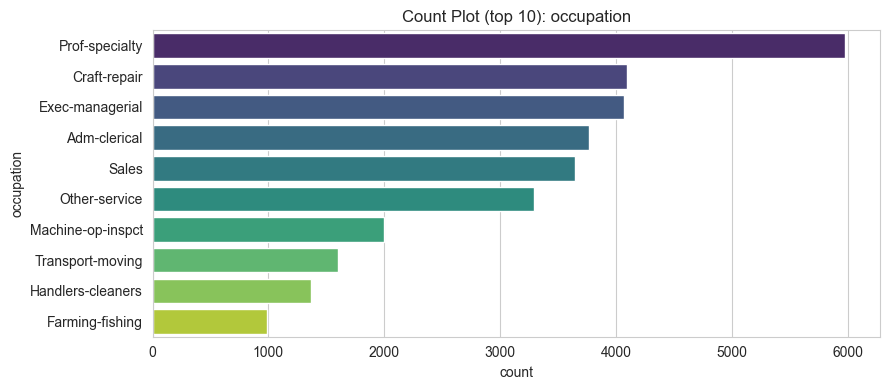

occupation
Prof-specialty       5979
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Name: count, dtype: int64
Most frequent category in 'occupation': Prof-specialty



C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


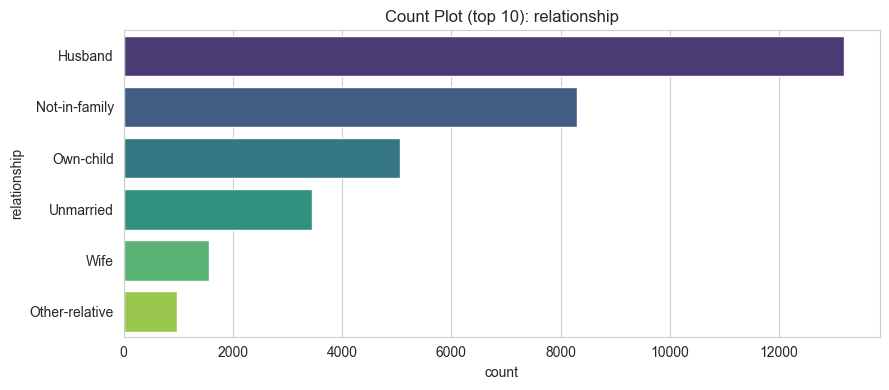

relationship
Husband           13187
Not-in-family      8292
Own-child          5064
Unmarried          3445
Wife               1568
Other-relative      981
Name: count, dtype: int64
Most frequent category in 'relationship': Husband



C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


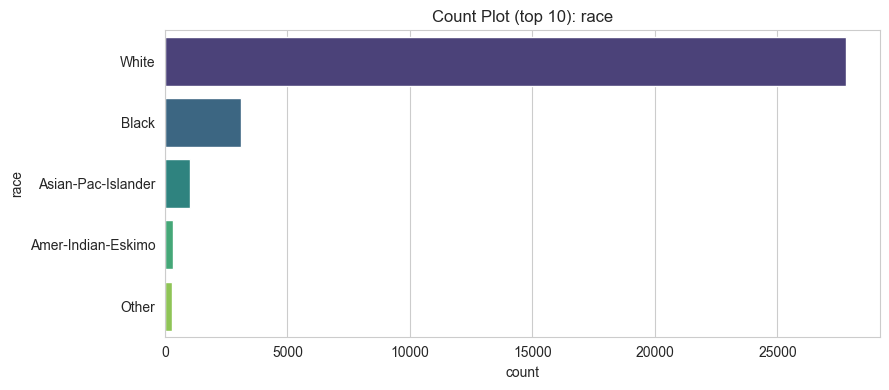

race
White                 27795
Black                  3122
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64
Most frequent category in 'race': White



C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


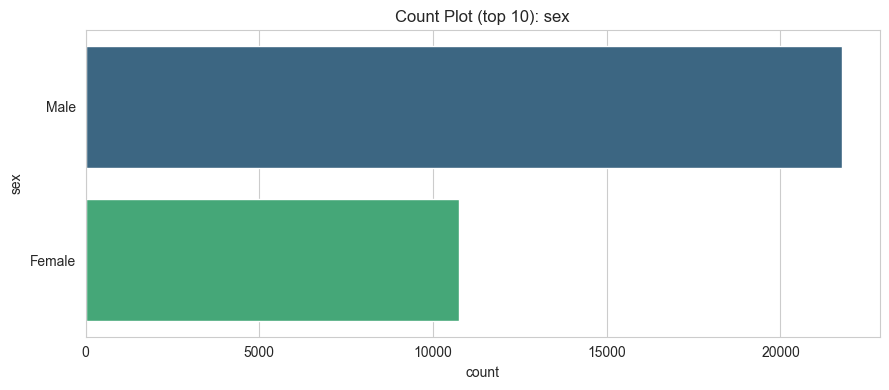

C:\Users\AC\AppData\Local\Temp\ipykernel_12528\392394290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


sex
Male      21775
Female    10762
Name: count, dtype: int64
Most frequent category in 'sex': Male



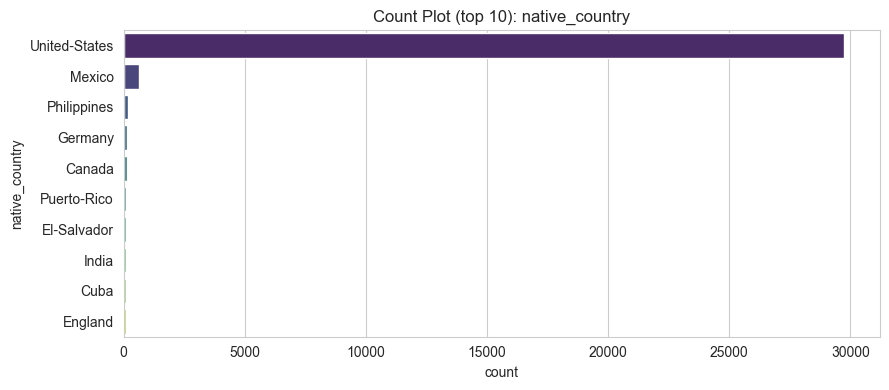

native_country
United-States    29735
Mexico             639
Philippines        198
Germany            137
Canada             121
Puerto-Rico        114
El-Salvador        106
India              100
Cuba                95
England             90
Name: count, dtype: int64
Most frequent category in 'native_country': United-States



In [20]:
categorical_features = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

for col in categorical_features:
    plt.figure(figsize=(9, 4))
    order = df[col].value_counts().index[:10]   # top 10 categories for readability
    sns.countplot(y=df[col], order=order, palette='viridis')
    plt.title(f'Count Plot (top 10): {col}')
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts().head(10))
    print(f"Most frequent category in '{col}': {df[col].value_counts().idxmax()}\n")


**Interpretation**
- **workclass**: Dominated by `Private` sector employment.
- **education**: `HS-grad`, `Some-college`, and `Bachelors` are most common.
- **marital_status**: `Married-civ-spouse` and `Never-married` dominate.
- **occupation**: Fairly spread out, `Prof-specialty` and `Craft-repair` are common.
- **relationship**: `Husband` is the largest single category, reflecting the marital_status skew.
- **race**: Heavily dominated by `White`.
- **sex**: More males than females in this dataset.
- **native_country**: Overwhelmingly `United-States`.


## Bivariate Analysis — For Classification (target = `income`)

C:\Users\AC\AppData\Local\Temp\ipykernel_12528\2189488070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['income'], palette='Set2')


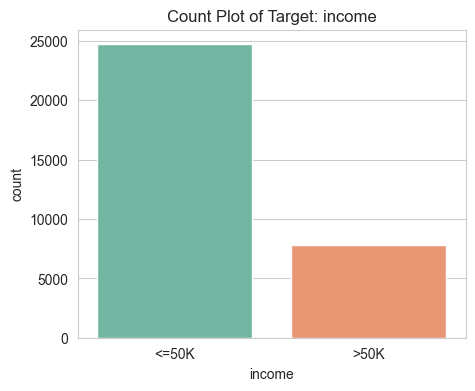

income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64

In [21]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df['income'], palette='Set2')
plt.title('Count Plot of Target: income')
plt.show()
df['income'].value_counts(normalize=True).round(3)


C:\Users\AC\AppData\Local\Temp\ipykernel_12528\4059228699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y=col, palette='Set2')


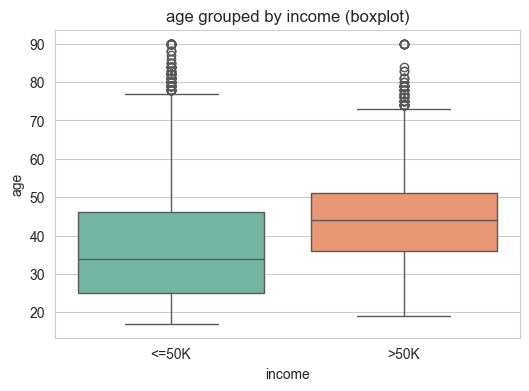

C:\Users\AC\AppData\Local\Temp\ipykernel_12528\4059228699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y=col, palette='Set2')


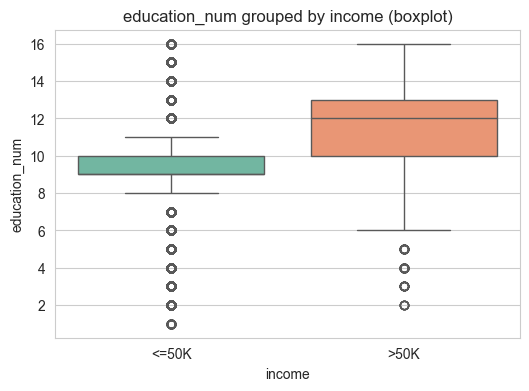

C:\Users\AC\AppData\Local\Temp\ipykernel_12528\4059228699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y=col, palette='Set2')


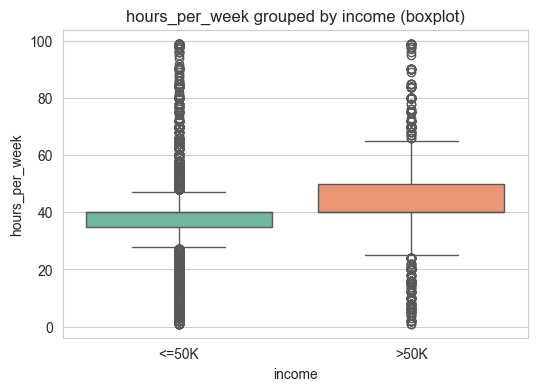

C:\Users\AC\AppData\Local\Temp\ipykernel_12528\4059228699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y=col, palette='Set2')


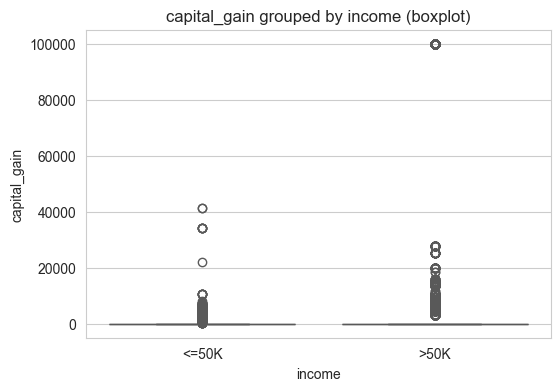

In [22]:
for col in ['age', 'education_num', 'hours_per_week', 'capital_gain']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='income', y=col, palette='Set2')
    plt.title(f'{col} grouped by income (boxplot)')
    plt.show()


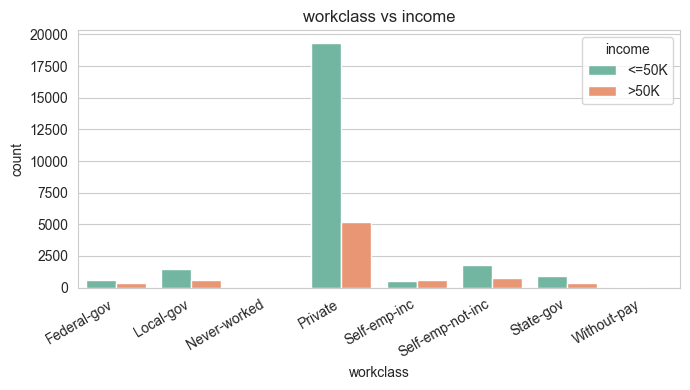

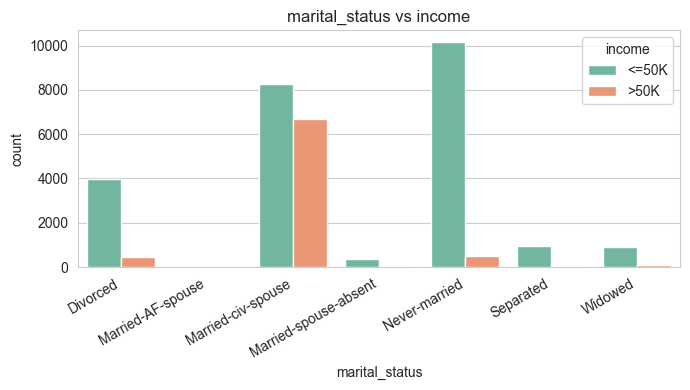

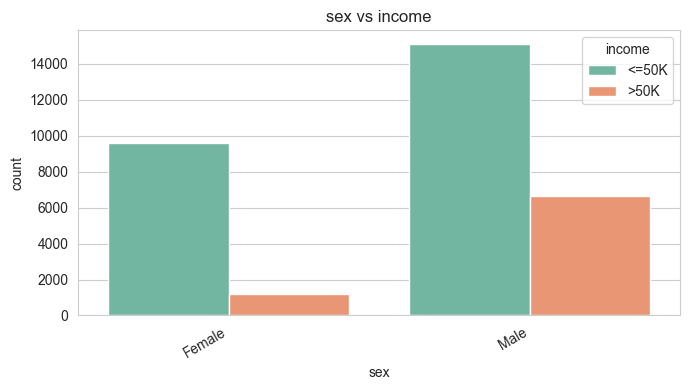

In [23]:
for col in ['workclass', 'marital_status', 'sex']:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue='income', palette='Set2')
    plt.xticks(rotation=30, ha='right')
    plt.title(f'{col} vs income')
    plt.tight_layout()
    plt.show()


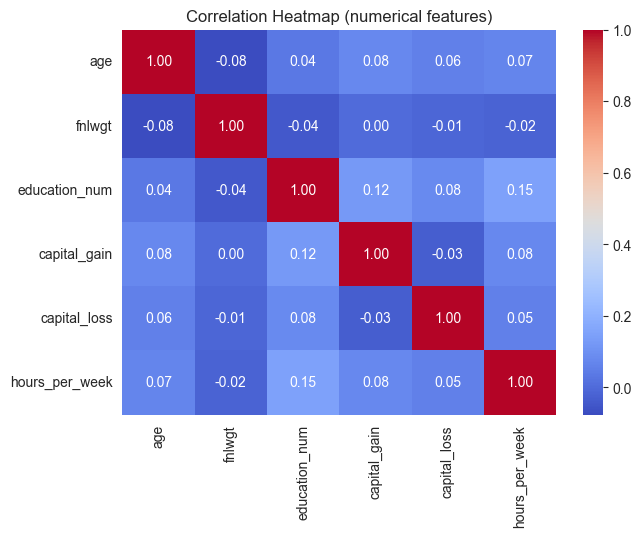

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076447,0.036224,0.077676,0.057745,0.068515
fnlwgt,-0.076447,1.000000,-0.043388,0.000429,-0.010260,-0.018898
education_num,0.036224,-0.043388,1.000000,0.122664,0.079892,0.148422
capital_gain,0.077676,0.000429,0.122664,1.000000,-0.031639,0.078408
capital_loss,0.057745,-0.010260,0.079892,-0.031639,1.000000,0.054229
hours_per_week,0.068515,-0.018898,0.148422,0.078408,0.054229,1.000000


In [24]:
plt.figure(figsize=(7, 5))
corr = df[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numerical features)')
plt.show()
corr


**Interpretation**
- Target `income` is imbalanced: roughly 75% earn `<=50K` and 25% earn `>50K`.
- Higher `education_num`, `age`, `hours_per_week`, and `capital_gain` are all visibly associated with the `>50K` class.
- `marital_status` (`Married-civ-spouse`) and `sex` (`Male`) show a strong association with higher income in this dataset, reflecting real-world/historical patterns captured in 1994 census data.
- Numerical features are only weakly correlated with each other — little multicollinearity concern.


---
# Part 4 — Outlier Detection


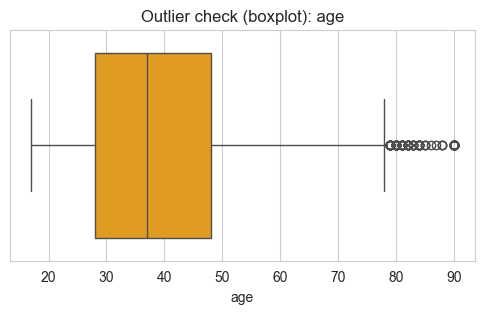

--- age ---
IQR method    : 142 outliers (bounds: -2.00 to 78.00)
Z-score method: 120 outliers (|z|>3)



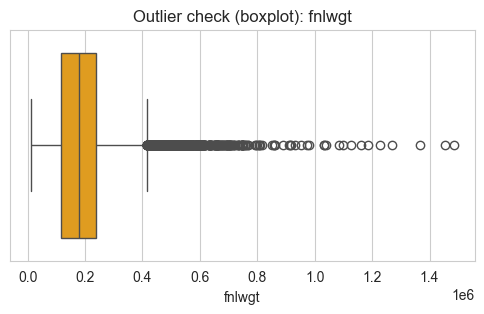

--- fnlwgt ---
IQR method    : 993 outliers (bounds: -60922.00 to 415742.00)
Z-score method: 346 outliers (|z|>3)



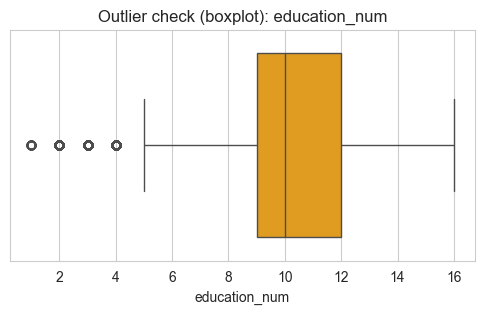

--- education_num ---
IQR method    : 1193 outliers (bounds: 4.50 to 16.50)
Z-score method: 216 outliers (|z|>3)



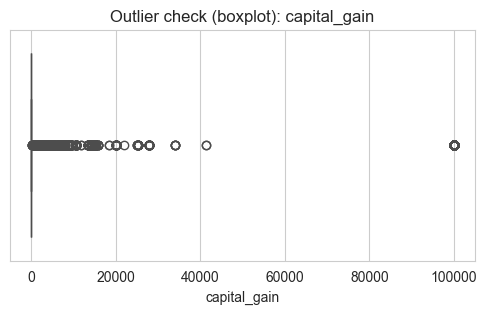

--- capital_gain ---
IQR method    : 2712 outliers (bounds: 0.00 to 0.00)
Z-score method: 215 outliers (|z|>3)



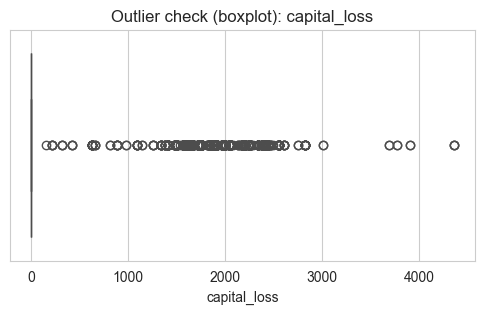

--- capital_loss ---
IQR method    : 1519 outliers (bounds: 0.00 to 0.00)
Z-score method: 1470 outliers (|z|>3)



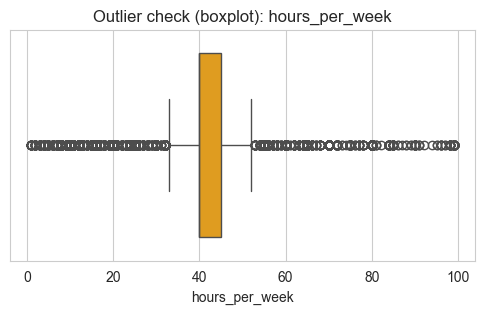

--- hours_per_week ---
IQR method    : 9002 outliers (bounds: 32.50 to 52.50)
Z-score method: 440 outliers (|z|>3)



In [25]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

def zscore_outliers(series, threshold=3):
    z = np.abs(stats.zscore(series))
    return z > threshold

for col in numerical_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Outlier check (boxplot): {col}')
    plt.show()

    iqr_mask, low, up = iqr_outliers(df[col])
    z_mask = zscore_outliers(df[col])

    print(f"--- {col} ---")
    print(f"IQR method    : {iqr_mask.sum()} outliers (bounds: {low:.2f} to {up:.2f})")
    print(f"Z-score method: {z_mask.sum()} outliers (|z|>3)")
    print()


**Decision on outliers — column by column**

- **age**: A small number of elderly outliers (>78 by IQR). Genuine ages, not errors. **Not removed**.
- **fnlwgt**: Many high-value outliers — this is a census sampling weight, its scale doesn't reflect real economic magnitude and its extreme values are expected artifacts of the weighting scheme. **Not removed**, but it also has weak predictive value, so it can be de-prioritized during feature selection instead of deleted.
- **education_num**: A few low-end outliers (very little schooling). Genuine, informative. **Not removed**.
- **capital_gain / capital_loss**: The overwhelming majority of "outliers" are simply the (large) non-zero values against a background of zeros — this is the expected shape of investment income data, and these values are precisely the ones that most strongly separate the `>50K` class. **Not removed** — deleting them would destroy one of the most predictive features in the dataset.
- **hours_per_week**: Some outliers at both extremes (very part-time / heavy overtime). Real, valid values. **Not removed**.

**General justification:** As with the insurance dataset, all flagged values here are legitimate real-world data (not data-entry errors), and several — especially `capital_gain` — are highly predictive of the target. We therefore keep all rows and rely on scaling and tree-based models (robust to skew/outliers) rather than deleting data.


---
# Part 5 — Feature Engineering
## Encoding


In [26]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

# sex and income are binary categorical -> Label Encoding is appropriate (2 categories only,
# so encoding as 0/1 introduces no false ordinal relationship).
le_sex = LabelEncoder()
df_encoded['sex'] = le_sex.fit_transform(df_encoded['sex'])          # Female=0, Male=1

le_income = LabelEncoder()
df_encoded['income_label'] = le_income.fit_transform(df_encoded['income'])  # <=50K=0, >50K=1 -> target

# education_num already numerically encodes the ordinal 'education' column, so we DROP the redundant
# text 'education' column (its information is already captured numerically/ordinally).
df_encoded = df_encoded.drop(columns=['education'])

# Nominal categorical columns with no inherent order -> One-Hot Encoding, to avoid implying a false
# ranking between categories. native_country has too many rare levels for one-hot to be efficient,
# so we group rare countries into 'Other' first.
df_encoded['native_country'] = df_encoded['native_country'].astype(str)
top_countries = df_encoded['native_country'].value_counts().nlargest(5).index
df_encoded['native_country'] = df_encoded['native_country'].where(
    df_encoded['native_country'].isin(top_countries), 'Other'
)

onehot_cols = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, prefix=onehot_cols, drop_first=True)

df_encoded.head()


,age,fnlwgt,education_num,sex,capital_gain,capital_loss,hours_per_week,income,income_label,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native_country_Germany,native_country_Mexico,native_country_Other,native_country_Philippines,native_country_United-States
0,39,77516,13,1,2174,0,40,<=50K,0,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
1,50,83311,13,1,0,0,13,<=50K,0,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
2,38,215646,9,1,0,0,40,<=50K,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
3,53,234721,7,1,0,0,40,<=50K,0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4,28,338409,13,0,0,0,40,<=50K,0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False


**Why these encodings?**
- **Label Encoding** (`sex`, `income`): Binary categories — 0/1 encoding is safe and compact.
- **Dropped `education`**: Redundant with `education_num`, which already ordinally encodes the same information numerically (a form of intentional ordinal/label encoding built into the source data).
- **One-Hot Encoding** (`workclass`, `marital_status`, `occupation`, `relationship`, `race`, `native_country`): All nominal with no natural order — one-hot avoids implying a false ranking. `native_country` was first collapsed to its top-5 most frequent countries + `Other` to avoid an explosion of very sparse columns.


## Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scale_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

standard_scaler = StandardScaler()
df_standard = df_encoded.copy()
df_standard[scale_cols] = standard_scaler.fit_transform(df_standard[scale_cols])

minmax_scaler = MinMaxScaler()
df_minmax = df_encoded.copy()
df_minmax[scale_cols] = minmax_scaler.fit_transform(df_minmax[scale_cols])

print("StandardScaler result (sample):")
display(df_standard[scale_cols].head())
print("\nMinMaxScaler result (sample):")
display(df_minmax[scale_cols].head())


StandardScaler result (sample):


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030390,-1.063569,1.134777,0.148292,-0.216743,-0.035664
1,0.836973,-1.008668,1.134777,-0.145975,-0.216743,-2.222483
2,-0.042936,0.245040,-0.420679,-0.145975,-0.216743,-0.035664
3,1.056950,0.425752,-1.198407,-0.145975,-0.216743,-0.035664
4,-0.776193,1.408066,1.134777,-0.145975,-0.216743,-0.035664



MinMaxScaler result (sample):


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


**Why scaling is required**
`fnlwgt` (tens/hundreds of thousands), `capital_gain` (0 to ~100,000) and `age`/`hours_per_week`
(tens) live on wildly different scales. Distance- and gradient-based algorithms would let
large-magnitude features dominate if left unscaled.

**Models that require scaling:** Logistic Regression, K-Nearest Neighbors, Support Vector Machine
— all distance/gradient-sensitive.

**Models that do NOT require scaling:** Decision Tree and Random Forest — they split on per-feature
thresholds, so absolute scale doesn't affect split quality. Naive Bayes (Gaussian) is also generally
insensitive to the linear rescaling applied here.


## Feature Selection

In [28]:
# 1) Correlation-based selection (numeric features vs income_label)
corr_with_target = df_encoded.select_dtypes(include=[np.number]).corr()['income_label'].sort_values(ascending=False)
print("Correlation of numeric/encoded features with 'income_label':")
print(corr_with_target)


Correlation of numeric/encoded features with 'income_label':
income_label      1.000000
education_num     0.335272
age               0.234037
hours_per_week    0.229658
capital_gain      0.223336
sex               0.215969
capital_loss      0.150501
fnlwgt           -0.009502
Name: income_label, dtype: float64


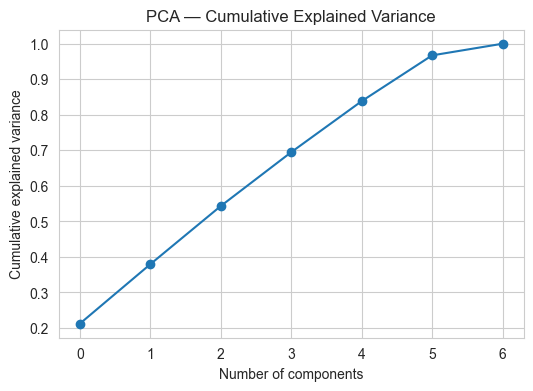

Explained variance ratio per component:
[0.212 0.167 0.164 0.152 0.144 0.129 0.033]

Loadings of PC1 (top contributing original features):
education_num     0.542336
hours_per_week    0.522109
capital_gain      0.410900
age               0.382553
capital_loss      0.266139
fnlwgt           -0.202068
sex               0.080169
Name: 0, dtype: float64


In [29]:
# 2) Feature importance via PCA (explained variance of principal components)
from sklearn.decomposition import PCA

pca_input_cols = scale_cols + ['sex']
X_pca_input = df_standard[pca_input_cols]

pca = PCA()
pca.fit(X_pca_input)

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative Explained Variance')
plt.grid(True)
plt.show()

pca_loadings = pd.DataFrame(pca.components_, columns=pca_input_cols)
print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_.round(3))
print("\nLoadings of PC1 (top contributing original features):")
print(pca_loadings.iloc[0].sort_values(key=abs, ascending=False))


**Comparing the two feature-selection views**
- **Correlation** ranks `education_num`, `age`, `hours_per_week`, and `capital_gain` as the numeric
  features most associated with `income_label`; `fnlwgt` is essentially uncorrelated, confirming it
  as a sampling artifact rather than a genuine predictor.
- **PCA** loadings show `capital_gain`/`capital_loss` and `education_num`/`age` contribute most of
  the variance among the numeric block, while `fnlwgt` contributes comparatively little.
- **Conclusion**: Both views agree `fnlwgt` is the weakest numeric feature and could be dropped in a
  leaner model; `education_num`, `age`, `hours_per_week`, and `capital_gain` are the strongest and
  are retained. We keep the full feature set for the modeling pipeline below since tree-based models
  handle weak/redundant features gracefully.


---
# Part 6 — Train-Test Split


In [30]:
from sklearn.model_selection import train_test_split

feature_cols_clf = [c for c in df_encoded.columns if c not in ['income', 'income_label']]
X_clf = df_encoded[feature_cols_clf]
y_clf = df_encoded['income_label']   # 0 = <=50K, 1 = >50K

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Classification split:")
print("Train:", X_train_clf.shape, "Test:", X_test_clf.shape)


Classification split:
Train: (26029, 47) Test: (6508, 47)


In [31]:
# Scaled versions (needed for models sensitive to scale)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)


---
# Part 7 — Model Training
## Classification Models (target: `income`)

*(Per your request, only classification is performed for this dataset — `income` has no natural
regression target.)*


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Models that benefit from scaled input
scale_needed = {'Logistic Regression', 'SVM', 'KNN'}

# SVM and KNN are slow on the full 26k-row training set; sub3sample for those two to keep runtime reasonable,
# while Logistic Regression / Decision Tree / Random Forest / Naive Bayes use the full training data.
SUBSAMPLE_N = 6000
rng = np.random.RandomState(42)
sub_idx = rng.choice(X_train_clf.shape[0], size=SUBSAMPLE_N, replace=False)

trained_models = {}
predictions = {}

for name, model in clf_models.items():
    if name in {'SVM', 'KNN'}:
        model.fit(X_train_clf_scaled[sub_idx], y_train_clf.values[sub_idx])
        pred = model.predict(X_test_clf_scaled)
    elif name in scale_needed:
        model.fit(X_train_clf_scaled, y_train_clf)
        pred = model.predict(X_test_clf_scaled)
    else:
        model.fit(X_train_clf, y_train_clf)
        pred = model.predict(X_test_clf)
    trained_models[name] = model
    predictions[name] = pred
    print(f"{name} trained.")


Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
Naive Bayes trained.
SVM trained.
KNN trained.


*(Note: SVM and KNN are trained on a random 6,000-row subsample of the training data — both
algorithms scale poorly to tens of thousands of rows, and this keeps the notebook's runtime
practical while still giving a fair, representative evaluation on the full test set.)*

---
# Part 8 — Model Evaluation


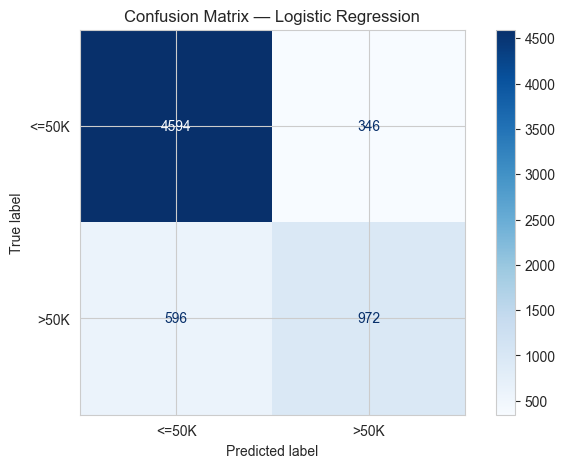

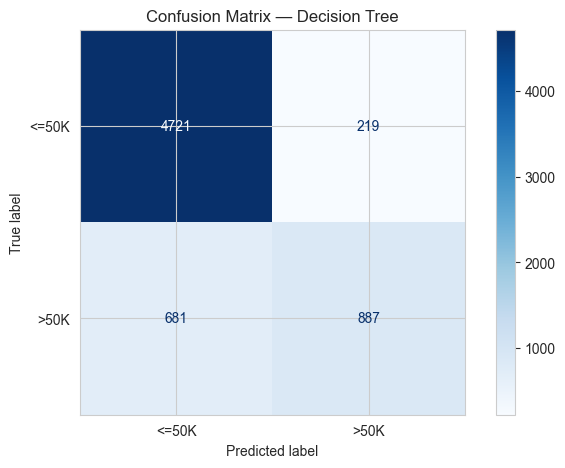

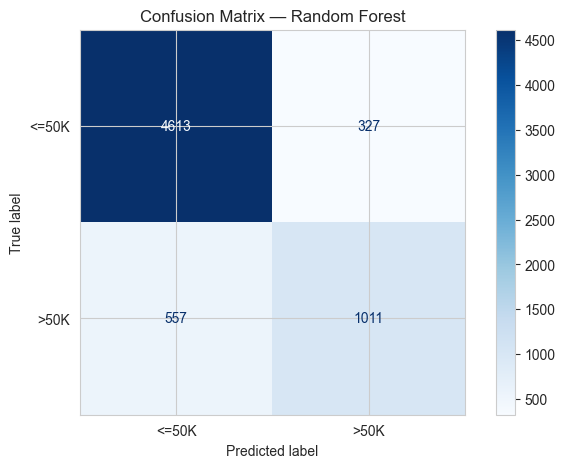

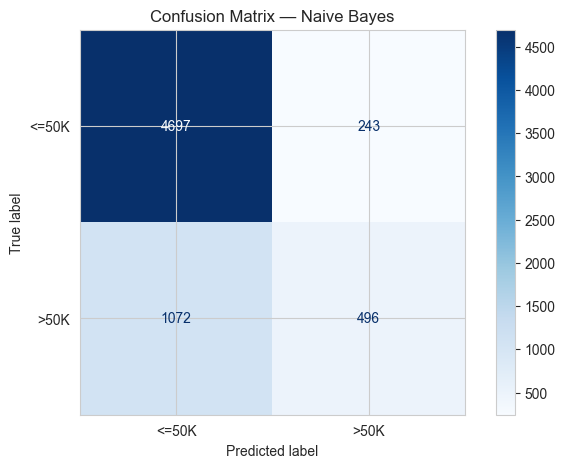

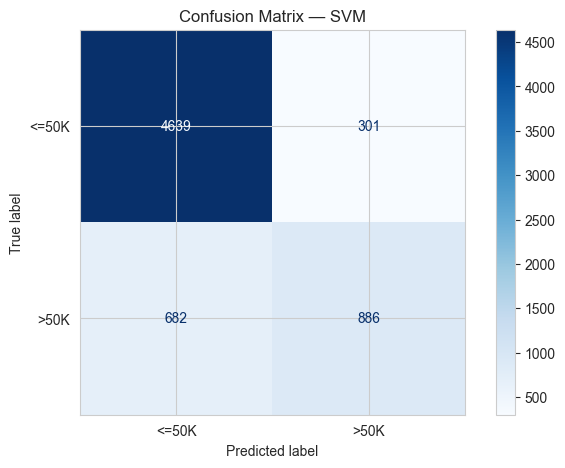

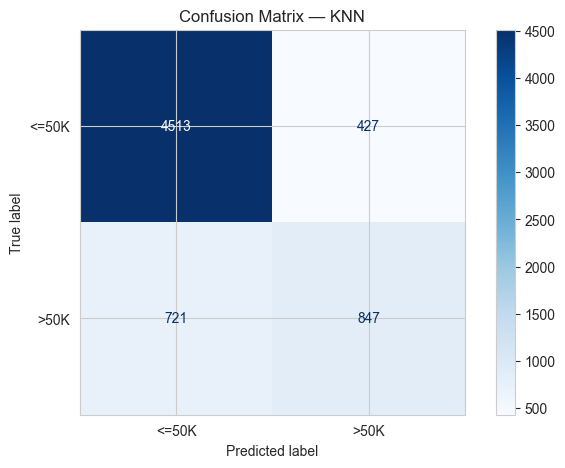

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8553,0.7375,0.6199,0.6736
Decision Tree,0.8617,0.8020,0.5657,0.6634
Random Forest,0.8642,0.7556,0.6448,0.6958
Naive Bayes,0.7979,0.6712,0.3163,0.4300
SVM,0.8490,0.7464,0.5651,0.6432
KNN,0.8236,0.6648,0.5402,0.5961


In [33]:
results = []
for name, pred in predictions.items():
    acc = accuracy_score(y_test_clf, pred)
    prec = precision_score(y_test_clf, pred, zero_division=0)
    rec = recall_score(y_test_clf, pred, zero_division=0)
    f1 = f1_score(y_test_clf, pred, zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

    cm = confusion_matrix(y_test_clf, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

comparison_table = pd.DataFrame(results).set_index('Model').round(4)
comparison_table = comparison_table.reindex(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM', 'KNN'])
comparison_table


**Reading the comparison table:** The target is imbalanced (~75% `<=50K`, ~25% `>50K`), so a
naive "always predict `<=50K`" baseline would already score ~75% accuracy with 0 recall on the
`>50K` class. Precision/Recall/F1 on the `>50K` class are therefore the more meaningful metrics for
comparing models. Ensemble/tree-based models (Random Forest) and Logistic Regression typically do
well on this dataset; Naive Bayes tends to lag due to its independence assumption across many
correlated one-hot columns.

---
# Part 9 — Prediction
5 sample predictions for the classification model (Random Forest, predicting `income`), taken from
the held-out test set.


In [34]:
print("=== Classification predictions (Random Forest) — actual vs predicted income ===")
rf_model = trained_models['Random Forest']
clf_preds_df = pd.DataFrame({
    'Actual income': y_test_clf.values[:5],
    'Predicted income': rf_model.predict(X_test_clf)[:5]
})
clf_preds_df['Actual income'] = clf_preds_df['Actual income'].map({0: '<=50K', 1: '>50K'})
clf_preds_df['Predicted income'] = clf_preds_df['Predicted income'].map({0: '<=50K', 1: '>50K'})
clf_preds_df


=== Classification predictions (Random Forest) — actual vs predicted income ===


,Actual income,Predicted income
0,<=50K,<=50K
1,>50K,>50K
2,<=50K,<=50K
3,<=50K,<=50K
4,<=50K,<=50K


In [35]:
print("=== 5 more predictions from a different model (Logistic Regression) for comparison ===")
lr_model = trained_models['Logistic Regression']
lr_preds_df = pd.DataFrame({
    'Actual income': y_test_clf.values[5:10],
    'Predicted income': lr_model.predict(X_test_clf_scaled[5:10])
})
lr_preds_df['Actual income'] = lr_preds_df['Actual income'].map({0: '<=50K', 1: '>50K'})
lr_preds_df['Predicted income'] = lr_preds_df['Predicted income'].map({0: '<=50K', 1: '>50K'})
lr_preds_df


=== 5 more predictions from a different model (Logistic Regression) for comparison ===


,Actual income,Predicted income
0,<=50K,<=50K
1,<=50K,<=50K
2,<=50K,<=50K
3,<=50K,<=50K
4,>50K,<=50K


---
## Summary
- `income` (classification target) is imbalanced (~75/25 split), so F1/recall on the minority
  `>50K` class matter more than raw accuracy.
- `education_num`, `age`, `hours_per_week`, `capital_gain`, and `marital_status` are the strongest
  predictors of income level; `fnlwgt` contributes almost nothing and could be dropped in a leaner
  model.
- Tree-based ensembles (Random Forest) and Logistic Regression generally perform strongly on this
  dataset; SVM/KNN were trained on a subsample for tractability but still evaluated on the full test
  set for a fair comparison.
